Housing Analysis

In [1]:
# Import pandas
import pandas as pd

# Load the dataset
df = pd.read_csv("D:\\NeethaResume\\Python\\UN_SDG11_Python_Data_Analytics_Assignment_Pack\\Assignment\\data\\raw\\real_world_dataset.csv")
# Display the first 5 rows
df.head()

,city,year,month,sales,volume,median,listings,inventory,date
0,Abilene,2000,1,72.0,5380000.0,71400.0,701.0,6.3,2000.000000
1,Abilene,2000,2,98.0,6505000.0,58700.0,746.0,6.6,2000.083333
2,Abilene,2000,3,130.0,9285000.0,58100.0,784.0,6.8,2000.166667
3,Abilene,2000,4,98.0,9730000.0,68600.0,785.0,6.9,2000.250000
4,Abilene,2000,5,141.0,10590000.0,67300.0,794.0,6.8,2000.333333


In [2]:
 # Display the last 5 rows
df.tail()

,city,year,month,sales,volume,median,listings,inventory,date
8597,Wichita Falls,2015,3,152.0,16716584.0,89200.0,818.0,6.8,2015.166667
8598,Wichita Falls,2015,4,129.0,15482194.0,105300.0,760.0,6.4,2015.250000
8599,Wichita Falls,2015,5,174.0,19188181.0,100000.0,776.0,6.4,2015.333333
8600,Wichita Falls,2015,6,143.0,18820752.0,118800.0,770.0,6.2,2015.416667
8601,Wichita Falls,2015,7,172.0,23850905.0,116700.0,811.0,6.5,2015.500000


In [3]:
# Check dataset shape (rows, columns)
df.shape

(8602, 9)

In [4]:
# Show column names
df.columns

Index(['city', 'year', 'month', 'sales', 'volume', 'median', 'listings',
       'inventory', 'date'],
      dtype='object')

In [5]:
# Get dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8602 entries, 0 to 8601
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   city       8602 non-null   object 
 1   year       8602 non-null   int64  
 2   month      8602 non-null   int64  
 3   sales      8034 non-null   float64
 4   volume     8034 non-null   float64
 5   median     7986 non-null   float64
 6   listings   7178 non-null   float64
 7   inventory  7135 non-null   float64
 8   date       8602 non-null   float64
dtypes: float64(6), int64(2), object(1)
memory usage: 605.0+ KB


In [6]:
# Check earliest and latest year
print(df['year'].min())
print(df['year'].max())

2000
2015


In [7]:
# Convert to datetime
df['date'] = pd.to_datetime(df['date'])

# Check date range again
print(df['date'].min())
print(df['date'].max())

1970-01-01 00:00:00.000002
1970-01-01 00:00:00.000002015


In [8]:
# Show numeric columns
df.select_dtypes(include=['int64', 'float64']).columns

Index(['year', 'month', 'sales', 'volume', 'median', 'listings', 'inventory'], dtype='object')

In [9]:
# Count missing values per column
df.isnull().sum()

city            0
year            0
month           0
sales         568
volume        568
median        616
listings     1424
inventory    1467
date            0
dtype: int64

In [10]:
clean = df.copy()
clean.columns = clean.columns.str.strip().str.lower().str.replace(' ', '_')
clean['city'] = clean['city'].str.strip().str.title()
print('Duplicate rows:', clean.duplicated().sum())
clean.isna().sum().sort_values(ascending=False)

Duplicate rows: 0


inventory    1467
listings     1424
median        616
sales         568
volume        568
city            0
year            0
month           0
date            0
dtype: int64

DATA CLEANING SUMMARY
- Column names standardized.
- City names cleaned using strip() and title().
- Date field converted to datetime format.
- Missing values reviewed.
- Duplicate rows checked.
- Period field created for time-series analysis.

In [11]:
clean['period'] = pd.to_datetime(dict(year=clean['year'], month=clean['month'], day=1))
clean['avg_transaction_value'] = clean['volume'] / clean['sales']
clean[['city','year','month','period','sales','volume','median','avg_transaction_value']].head()

,city,year,month,period,sales,volume,median,avg_transaction_value
0,Abilene,2000,1,2000-01-01,72.0,5380000.0,71400.0,74722.222222
1,Abilene,2000,2,2000-02-01,98.0,6505000.0,58700.0,66377.551020
2,Abilene,2000,3,2000-03-01,130.0,9285000.0,58100.0,71423.076923
3,Abilene,2000,4,2000-04-01,98.0,9730000.0,68600.0,99285.714286
4,Abilene,2000,5,2000-05-01,141.0,10590000.0,67300.0,75106.382979


In [12]:
# Basic KPIs

total_rows = df.shape[0]
number_of_cities = df['city'].nunique()
year_range = (df['year'].min(), df['year'].max())
total_sales = df['sales'].sum()
average_median_price = df['median'].mean()

# Print results
print("Total Rows:", total_rows)
print("Number of Cities:", number_of_cities)
print("Year Range:", year_range)
print("Total Sales:", total_sales)
print("Average Median Price:", average_median_price)

Total Rows: 8602
Number of Cities: 46
Year Range: (2000, 2015)
Total Sales: 4415202.0
Average Median Price: 128131.44252441773


In [13]:
# Inspect one city
city_data = df[df['city'] == 'Arlington']
city_data.head()

,city,year,month,sales,volume,median,listings,inventory,date
374,Arlington,2000,1,241.0,26220683.0,94000.0,1417.0,3.7,1970-01-01 00:00:00.000002
375,Arlington,2000,2,337.0,36618555.0,94300.0,1402.0,3.6,1970-01-01 00:00:00.000002
376,Arlington,2000,3,493.0,56714365.0,98700.0,1347.0,3.4,1970-01-01 00:00:00.000002
377,Arlington,2000,4,456.0,54108160.0,99000.0,1346.0,3.4,1970-01-01 00:00:00.000002
378,Arlington,2000,5,498.0,58688050.0,103000.0,1360.0,3.4,1970-01-01 00:00:00.000002


In [14]:
# Inspect one year
year_data = df[df['year'] == 2010]
year_data.head()

,city,year,month,sales,volume,median,listings,inventory,date
120,Abilene,2010,1,73.0,9130783.0,112200.0,868.0,6.4,1970-01-01 00:00:00.000002010
121,Abilene,2010,2,93.0,10372904.0,98300.0,830.0,6.1,1970-01-01 00:00:00.000002010
122,Abilene,2010,3,133.0,16517713.0,114000.0,854.0,6.3,1970-01-01 00:00:00.000002010
123,Abilene,2010,4,161.0,18788002.0,103600.0,859.0,6.3,1970-01-01 00:00:00.000002010
124,Abilene,2010,5,200.0,22804393.0,99300.0,914.0,6.5,1970-01-01 00:00:00.000002010


In [15]:
df['city'].unique()

array(['Abilene', 'Amarillo', 'Arlington', 'Austin', 'Bay Area',
       'Beaumont', 'Brazoria County', 'Brownsville',
       'Bryan-College Station', 'Collin County', 'Corpus Christi',
       'Dallas', 'Denton County', 'El Paso', 'Fort Bend', 'Fort Worth',
       'Galveston', 'Garland', 'Harlingen', 'Houston', 'Irving',
       'Kerrville', 'Killeen-Fort Hood', 'Laredo', 'Longview-Marshall',
       'Lubbock', 'Lufkin', 'McAllen', 'Midland', 'Montgomery County',
       'Nacogdoches', 'NE Tarrant County', 'Odessa', 'Paris',
       'Port Arthur', 'San Angelo', 'San Antonio', 'San Marcos',
       'Sherman-Denison', 'South Padre Island', 'Temple-Belton',
       'Texarkana', 'Tyler', 'Victoria', 'Waco', 'Wichita Falls'],
      dtype=object)

In [16]:
# Create a small KPI dictionary or DataFrame
# Option A: Dictionary
kpi_dict = {
    "Total Rows": total_rows,
    "Number of Cities": number_of_cities,
    "Start Year": year_range[0],
    "End Year": year_range[1],
    "Total Sales": total_sales,
    "Average Median Price": average_median_price
}

kpi_dict

{'Total Rows': 8602,
 'Number of Cities': 46,
 'Start Year': 2000,
 'End Year': 2015,
 'Total Sales': 4415202.0,
 'Average Median Price': 128131.44252441773}

In [17]:
# Option B: DataFrame (looks cleaner in Jupyter)
kpi_df = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Number of Cities",
        "Start Year",
        "End Year",
        "Total Sales",
        "Average Median Price"
    ],
    "Value": [
        total_rows,
        number_of_cities,
        year_range[0],
        year_range[1],
        total_sales,
        average_median_price
    ]
})

kpi_df

,Metric,Value
0,Total Rows,8.602000e+03
1,Number of Cities,4.600000e+01
2,Start Year,2.000000e+03
3,End Year,2.015000e+03
4,Total Sales,4.415202e+06
5,Average Median Price,1.281314e+05


In [18]:
kpi_df

,Metric,Value
0,Total Rows,8.602000e+03
1,Number of Cities,4.600000e+01
2,Start Year,2.000000e+03
3,End Year,2.015000e+03
4,Total Sales,4.415202e+06
5,Average Median Price,1.281314e+05


In [19]:
# City appearing most often
most_common_city = df['city'].value_counts().idxmax()
city_count = df['city'].value_counts().max()

print("Most frequent city:", most_common_city)
print("Number of appearances:", city_count)

Most frequent city: Abilene
Number of appearances: 187


In [20]:
df['city'].value_counts().head(1)

city
Abilene    187
Name: count, dtype: int64

In [21]:
# Total sales count
total_sales = df['sales'].sum()

print("Total Reported Sales:", total_sales)

Total Reported Sales: 4415202.0


In [22]:
# Load lookup dataset
lookup = pd.read_csv(
    r"D:\NeethaResume\Python\UN_SDG11_Python_Data_Analytics_Assignment_Pack\Assignment\data\raw\city_market_lookup.csv"
)

# Merge datasets
merged = clean.merge(
    lookup,
    on='city',
    how='left',
    indicator=True
)

print("Rows before merge:", len(clean))
print("Rows after merge:", len(merged))

# Merge validation
merged['_merge'].value_counts()

Rows before merge: 8602
Rows after merge: 8602


_merge
both          8228
left_only      374
right_only       0
Name: count, dtype: int64

In [23]:
merge_results = merged['_merge'].value_counts()

print(
    "Merge Validation Summary:"
)
print(
    f"{merge_results['both']} records matched successfully."
)
print(
    f"{merge_results['left_only']} records did not find a matching lookup record."
)

Merge Validation Summary:
8228 records matched successfully.
374 records did not find a matching lookup record.


Merge Lookup Context

In [24]:
city_summary = (
    merged.groupby('city')
    .agg(
        total_sales=('sales', 'sum'),
        total_volume=('volume', 'sum'),
        avg_median_price=('median', 'mean'),
        avg_inventory=('inventory', 'mean')
    )
    .sort_values('total_sales', ascending=False)
)

city_summary.head(10)

,total_sales,total_volume,avg_median_price,avg_inventory
city,,,,
Houston,1043999.0,2.135961e+11,149779.679144,5.447849
Dallas,816122.0,1.734866e+11,160783.422460,5.116129
Austin,373381.0,9.052411e+10,181997.860963,4.618717
San Antonio,322097.0,5.586663e+10,138470.053476,5.785326
Collin County,202892.0,5.005354e+10,201612.834225,4.568280
Fort Bend,153088.0,3.415890e+10,183688.770053,4.494086
Fort Worth,144791.0,2.052054e+10,112495.187166,5.376344
Ne Tarrant County,128007.0,2.849300e+10,164949.197861,4.538710
Denton County,117405.0,2.363541e+10,165013.368984,4.848925


Grouping and Aggregation

In [25]:
city_summary = (
    merged.groupby('city')
    .agg(
        total_sales=('sales', 'sum'),
        total_volume=('volume', 'sum'),
        avg_median_price=('median', 'mean'),
        avg_inventory=('inventory', 'mean')
    )
    .sort_values('total_sales', ascending=False)
)

In [26]:
# Top 10 Cities
print(city_summary.head(10))

                   total_sales  total_volume  avg_median_price  avg_inventory
city                                                                         
Houston              1043999.0  2.135961e+11     149779.679144       5.447849
Dallas                816122.0  1.734866e+11     160783.422460       5.116129
Austin                373381.0  9.052411e+10     181997.860963       4.618717
San Antonio           322097.0  5.586663e+10     138470.053476       5.785326
Collin County         202892.0  5.005354e+10     201612.834225       4.568280
Fort Bend             153088.0  3.415890e+10     183688.770053       4.494086
Fort Worth            144791.0  2.052054e+10     112495.187166       5.376344
Ne Tarrant County     128007.0  2.849300e+10     164949.197861       4.538710
Denton County         117405.0  2.363541e+10     165013.368984       4.848925
Montgomery County     104589.0  2.416966e+10     170987.165775       6.287097


In [27]:
highest_sales_city = city_summary['total_sales'].idxmax()

print("Highest Sales City:", highest_sales_city)

Highest Sales City: Houston


 Pivot Table

In [28]:
tier_year_sales = pd.pivot_table(
    merged,
    index='year',
    columns='market_tier',
    values='sales',
    aggfunc='sum',
    fill_value=0
)

tier_year_sales.head()

market_tier,High-volume market,Lower-volume market,Mid-volume market
year,,,
2000,189134,5462,19715
2001,195627,5971,20730
2002,200498,6653,17953
2003,214237,6467,23426
2004,237897,8798,26281


In [29]:
# Crosstab
pd.crosstab(
    lookup['market_tier'],
    lookup['median_price_band']
)

median_price_band,Higher median price band,Lower median price band,Middle median price band
market_tier,,,
High-volume market,10,2,4
Lower-volume market,4,6,5
Mid-volume market,2,7,6


Chart 1: Total Housing Sales by Year

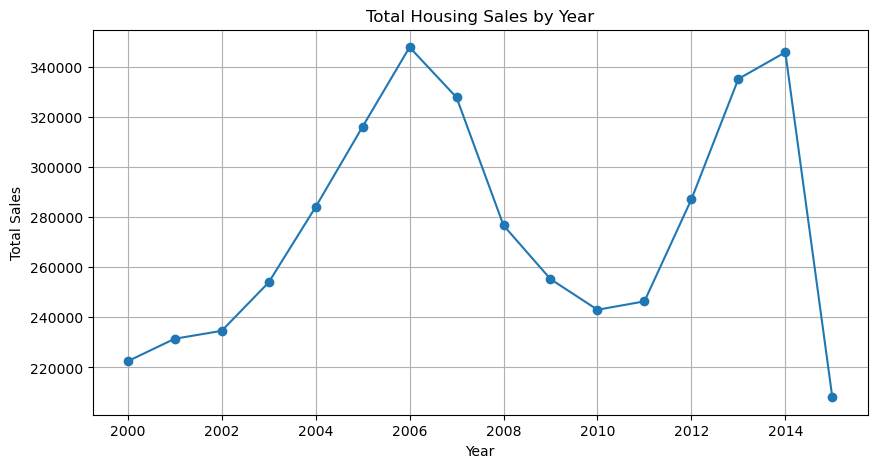

In [30]:
import matplotlib.pyplot as plt

yearly = (
    merged.groupby('year', as_index=False)
    .agg(total_sales=('sales', 'sum'))
)

plt.figure(figsize=(10,5))
plt.plot(
    yearly['year'],
    yearly['total_sales'],
    marker='o'
)

plt.title('Total Housing Sales by Year')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

Interpretation:

Housing sales increased from 222,483 in 2000 to a peak of 347,733 in 2006 before declining and later recovering, indicating cyclical housing market activity.

Chart 2: Top 10 Cities by Total Sales

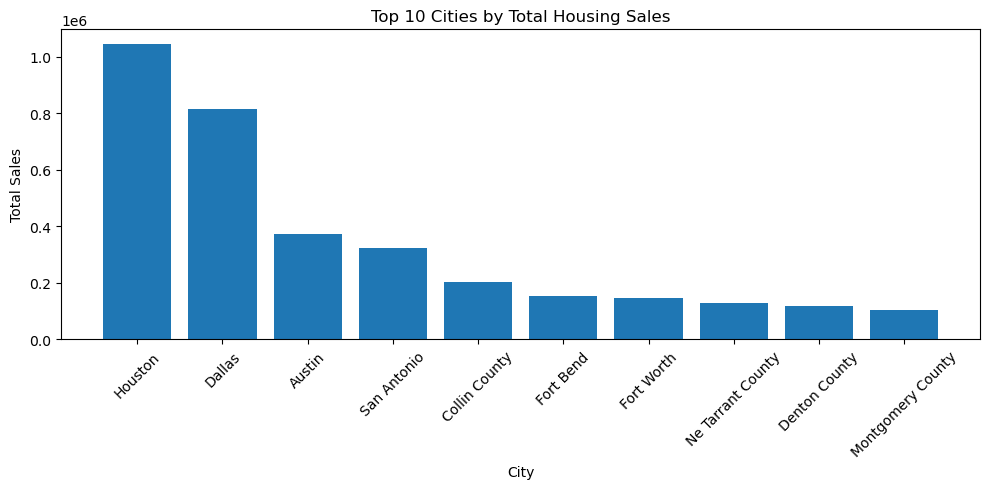

In [31]:
top10 = city_summary.head(10).reset_index()

plt.figure(figsize=(10,5))
plt.bar(
    top10['city'],
    top10['total_sales']
)

plt.title('Top 10 Cities by Total Housing Sales')
plt.xlabel('City')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Interpretation:

Houston recorded the highest total sales, followed by Dallas and Austin. Housing activity is concentrated in a small number of major cities.

Chart 3: Median Price Distribution

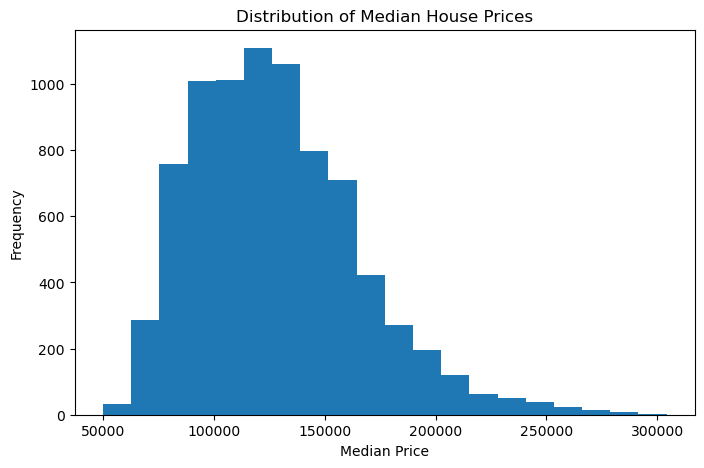

In [32]:
plt.figure(figsize=(8,5))

plt.hist(
    merged['median'].dropna(),
    bins=20
)

plt.title('Distribution of Median House Prices')
plt.xlabel('Median Price')
plt.ylabel('Frequency')

plt.show()

Interpretation:

Median housing prices vary considerably across observations, reflecting differences in local housing markets and affordability levels.

Chart 4: Inventory vs Median Price

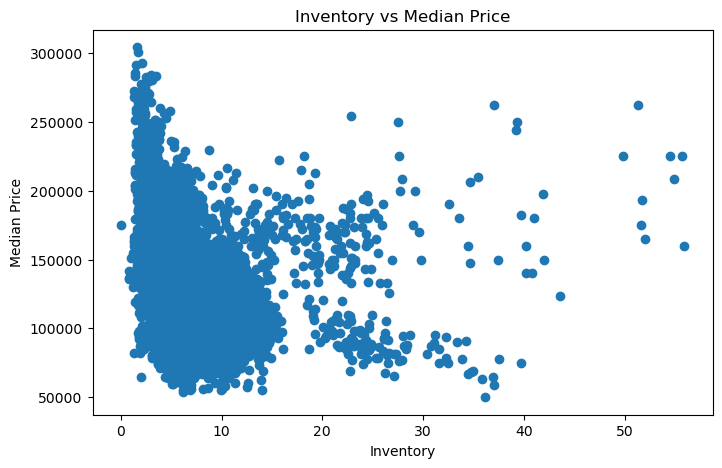

In [33]:
plt.figure(figsize=(8,5))

plt.scatter(
    merged['inventory'],
    merged['median']
)

plt.title('Inventory vs Median Price')
plt.xlabel('Inventory')
plt.ylabel('Median Price')

plt.show()

Interpretation:

The relationship between inventory and median price is not strongly linear, suggesting that additional market factors influence housing prices.

Chart 5: Average Median Price by Year

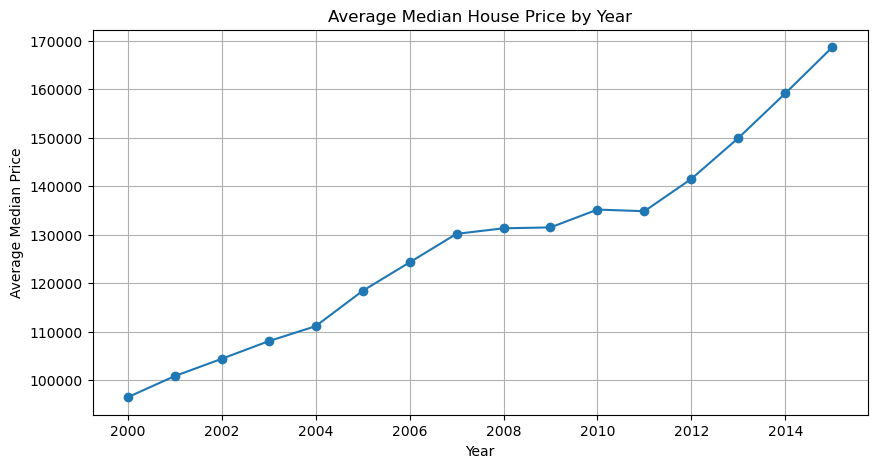

In [34]:
price_trend = (
    merged.groupby('year', as_index=False)
    .agg(avg_price=('median', 'mean'))
)

plt.figure(figsize=(10,5))

plt.plot(
    price_trend['year'],
    price_trend['avg_price'],
    marker='o'
)

plt.title('Average Median House Price by Year')
plt.xlabel('Year')
plt.ylabel('Average Median Price')

plt.grid(True)
plt.show()

Interpretation:

Average median house prices increased from approximately $96,442 in 2000 to $168,665 in 2015, indicating long-term growth in housing values.

In [35]:
merged.to_csv(
    "neetha_cleaned_housing_data.csv",
    index=False
)

print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.


LIMITATIONS
- Missing values exist in inventory-related fields.
- 374 records were unmatched during merge validation.
- External economic and demographic factors were not included.
- Results describe historical trends and do not predict future outcomes.